In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [49]:
# use pip install rdkit (instead of conda install rdkit, which causes problems)
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Draw

In [50]:
# One can draw a molecule in ChemDraw, and then save the molecule structures as .mol file. 

# Read molecule from .mol file
mol_file = "benzene.mol"  # Update with the actual path to your .mol file
mol = Chem.MolFromMolFile(mol_file)

In [51]:
# Convert the molecule object to a SMILES string
smiles_output = Chem.MolToSmiles(mol)
print("SMILES String:", smiles_output)

SMILES String: c1ccccc1


In [52]:
# Alternatively, one can create molecule from a SMILES string
mol = Chem.MolFromSmiles('Cc1ccccc1')

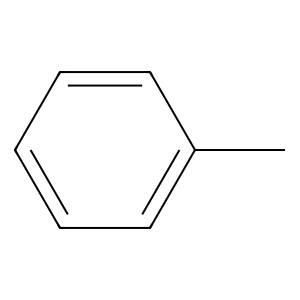

In [53]:
# Draw the molecule
img = Draw.MolToImage(mol)
img

In [54]:
# Save an image for a molecule
Draw.MolToFile(mol, 'mol.png')

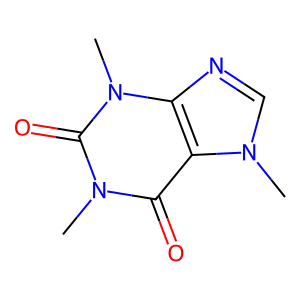

In [55]:
# define the smiles string and covert it into a molecule sturcture ------------
caffeine_smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'

mol = Chem.MolFromSmiles(caffeine_smiles)

# draw the modecule -----------------------------------------------------------
Draw.MolToImage(mol)

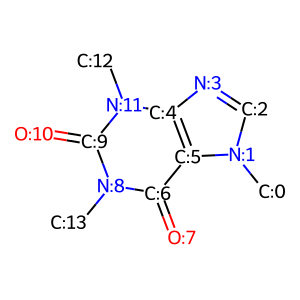

In [56]:
# draw the molecule with property ---------------------------------------------
for i, atom in enumerate(mol.GetAtoms()):
    atom.SetProp("molAtomMapNumber", str(atom.GetIdx()))
    
Draw.MolToImage(mol)

In [57]:
# print the atoms of the molecule ---------------------------------------------
for atom in mol.GetAtoms():
    print(atom.GetIdx(),',',
          atom.GetAtomicNum(),',',
          atom.GetIsAromatic(),',',
          atom.GetSymbol())
    
# print the bonds of the molecule ---------------------------------------------
for bond in mol.GetBonds():
    print(bond.GetBeginAtomIdx(),',',
          bond.GetEndAtomIdx(),',',
          bond.GetBondType())

0 , 6 , False , C
1 , 7 , True , N
2 , 6 , True , C
3 , 7 , True , N
4 , 6 , True , C
5 , 6 , True , C
6 , 6 , True , C
7 , 8 , False , O
8 , 7 , True , N
9 , 6 , True , C
10 , 8 , False , O
11 , 7 , True , N
12 , 6 , False , C
13 , 6 , False , C
0 , 1 , SINGLE
1 , 2 , AROMATIC
2 , 3 , AROMATIC
3 , 4 , AROMATIC
4 , 5 , AROMATIC
5 , 6 , AROMATIC
6 , 7 , DOUBLE
6 , 8 , AROMATIC
8 , 9 , AROMATIC
9 , 10 , DOUBLE
9 , 11 , AROMATIC
11 , 12 , SINGLE
8 , 13 , SINGLE
5 , 1 , AROMATIC
11 , 4 , AROMATIC


In [58]:
# Generating Molecular Fingerprint from a SMILES String
from rdkit.Chem import RDKFingerprint
from rdkit.Chem import rdMolDescriptors

# define the smiles string and covert it into a molecule sturcture ------------
caffeine_smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'

mol = Chem.MolFromSmiles(caffeine_smiles)

# retrieving RDK Fingerprint (Daylight fingerprint), which is path-based (topological) fingerprints -------------------------------------------------
# this is not often used these days.
bit_info = {}
fingerprint_rdk = RDKFingerprint(mol, maxPath=5, bitInfo=bit_info)
print(">>> RDK Fingerprint = ", fingerprint_rdk)

fingerprint_rdk_np = np.array(fingerprint_rdk)
print(">>> RDK Fingerprint in numpy = ", fingerprint_rdk_np)
print(">>> RDK Fingerprint in numpy shape = ", fingerprint_rdk_np.shape)

print()

print(list(fingerprint_rdk.GetOnBits())[:10])  # print the first 10 bits set to 1

>>> RDK Fingerprint =  <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x7f0b8db68e40>
>>> RDK Fingerprint in numpy =  [1 0 0 ... 0 0 1]
>>> RDK Fingerprint in numpy shape =  (2048,)

[0, 5, 14, 57, 97, 103, 104, 117, 118, 126]


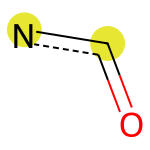

In [59]:
# using the bit_info dictionary populated by RDKit prepare a visualisation
Draw.DrawRDKitBit(mol, 57, bit_info)

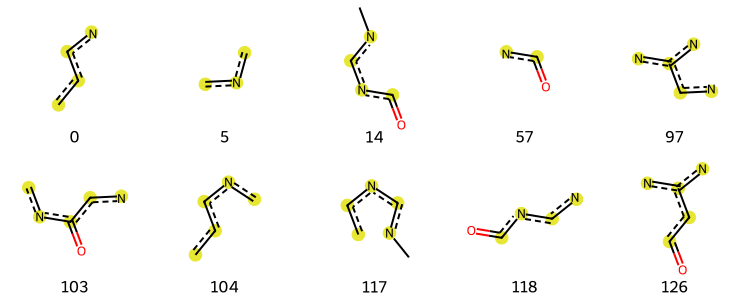

In [61]:
# draw multiple bits (10)
tpls = [(mol, x, bit_info) for x in bit_info]
Draw.DrawRDKitBits(tpls[:10], molsPerRow=5, legends=[str(x) for x in bit_info][:10])

In [66]:
# retrieving Morgan Fingerprint ----------------------------------------------- 
# more often used than RDKit Fingerprint

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, AdditionalOutput
import numpy as np

bit_info = {}

# this is just for demo. In practice, fgSize should be much larger, e.g., 1024 and 2048 to avoid collisions.
gen = GetMorganGenerator(radius=2, fpSize=256)

ao = AdditionalOutput()
ao.AllocateBitInfoMap()

fingerprint_morgan = gen.GetFingerprint(
    mol,
    additionalOutput=ao
)

bit_info = ao.GetBitInfoMap()

print(">>> Morgan Fingerprint =", fingerprint_morgan)

fingerprint_morgan_np = np.array(fingerprint_morgan)
print(">>> Morgan Fingerprint in numpy:", fingerprint_morgan_np)
print(">>> Morgan Fingerprint in numpy shape =", fingerprint_morgan_np.shape)

print(bit_info)

>>> Morgan Fingerprint = <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x7f0b8db6b8b0>
>>> Morgan Fingerprint in numpy: [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
>>> Morgan Fingerprint in numpy shape = (256,)
{0: ((11, 2),), 3: ((9, 1),), 27: ((6, 2),), 33: ((0, 0), (12, 0), (13, 0), (4, 2)), 52: ((8, 1), (11, 1)), 58: ((7, 1), (10, 1)), 74: ((5, 2),), 81: ((2, 0),), 100: ((4, 0), (5, 0), (6, 0), (9, 0)), 121: ((0, 1), (12, 1), (13, 1)), 122: ((3, 0),), 129: ((1, 1),), 138: ((7, 0), (10, 0)), 144: ((9, 2)

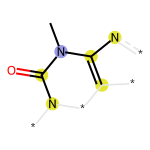

In [67]:
# draw 0: ((11, 2),) 
Draw.DrawMorganBit(mol, 0, bit_info, useSVG=True)
# 0: bit 0
# 11: the index of the atom at the center (blue)
# 2: includes atoms within 2 bonds (yellow: aromatic atoms; gray: aliphatic ring atoms)

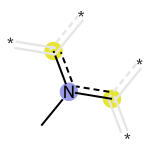

In [68]:
# draw 52: ((8, 1), (11, 1))
Draw.DrawMorganBit(mol, 52, bit_info, useSVG=True)

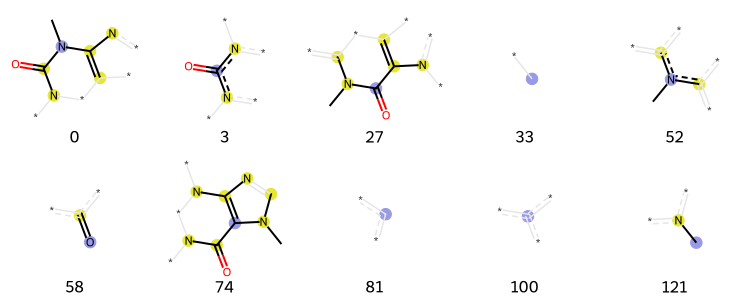

In [69]:
# draw multiple bits (10)
tpls = [(mol, x, bit_info) for x in bit_info]
Draw.DrawMorganBits(tpls[:10], molsPerRow=5, legends=[str(x) for x in bit_info][:10])

Ref.: https://medium.com/data-science/basic-molecular-representation-for-machine-learning-b6be52e9ff76